In [1]:
import subprocess, os, shutil

REPO_URL = "https://github.com/safety-research/legibility.git"
REPO_DIR = "/workspace/18-4-2026"
EXP_DIR = os.path.join(REPO_DIR, "experiments", "2026", "15-4-2026")

# Clone or pull latest (fetch + reset to ensure we have the newest commit)
if not os.path.exists(os.path.join(REPO_DIR, ".git")):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin"], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "reset", "--hard", "origin/main"], check=True)


# Download results data from HuggingFace (too large for git)
from huggingface_hub import hf_hub_download
RESULTS_DIR = os.path.join(EXP_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)
for fname in ["classifications.json", "cot_texts.json"]:
    target = os.path.join(RESULTS_DIR, fname)
    if not os.path.exists(target):
        print(f"Downloading {fname} from HuggingFace...")
        hf_hub_download(
            repo_id="Noddybear/legibility-data",
            filename=f"results/{fname}",
            repo_type="dataset",
            local_dir=EXP_DIR,
        )
    else:
        print(f"CACHED: {fname}")

# Install dependencies
req_path = os.path.join(EXP_DIR, "requirements.txt")
if os.path.exists(req_path):
    subprocess.run(["pip", "install", "-q", "-r", req_path], check=True)
else:
    print(f"WARNING: {req_path} not found, skipping pip install")

# Set working directory so Path.cwd().parent resolves to experiment root
os.chdir(os.path.join(EXP_DIR, "notebooks"))

HEAD is now at c90b5e7 Fix Gemma 4 nested config: num_hidden_layers is under text_config


In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from phase2_utils import PHASE2_RESULTS_DIR

_output_path = PHASE2_RESULTS_DIR / 'reader_r5_analysis_results.json'
if _output_path.exists():
    import json as _json
    with open(_output_path) as _f:
        _saved = _json.load(_f)
    _has_per_gen = 'per_generator_c2' in _saved
    print(f"CACHED: {_output_path} exists.")
    for key in _saved:
        n_layers = len(_saved[key]) if isinstance(_saved[key], dict) else 'N/A'
        print(f"  {key}: {n_layers} layers")
    if not _has_per_gen:
        print("NOTE: per_generator_c2 not yet computed -- will re-run.")
    else:
        print("Delete this file and re-run to recompute.")
else:
    print("No cached R5 analysis results -- will compute from scratch.")

# NB07b: Reader R5 Activation Analysis (Experiment D)

**CPU notebook** (~15 min). Analyzes R5 activations to understand what happens
inside the Google-lineage reader when it succeeds vs fails at C2 crossfill.

Mirrors NB07 (R2 analysis) but uses R5 (Gemma-4-31B-IT) activations.
Together with R2, this tests whether reader-side patterns generalize across
model families (Meta vs Google).

**Requires:** NB02b outputs (`activations/R5_last_token/`, `activations/R5_cot_boundary/`)
**Optional:** NB10b outputs (`distributional_shift_scores.json` with R5 entries) for perplexity covariate

In [3]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

sys.path.insert(0, str(Path.cwd().parent))
from phase2_utils import (
    load_activations, load_distributional_shift_scores, train_binary_probe,
    permutation_test, plot_layer_probe_curve, bootstrap_ci_metric,
    ACTIVATIONS_DIR, PHASE2_RESULTS_DIR,
)

PHASE2_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
# Load R5 activations and metadata
r5_last = load_activations(ACTIVATIONS_DIR / "R5_last_token")
r5_boundary = load_activations(ACTIVATIONS_DIR / "R5_cot_boundary")

with open(ACTIVATIONS_DIR / "R5_last_token" / "metadata.json") as f:
    r5_meta = json.load(f)

r5_labels = np.array(r5_meta['labels'])  # 1=C2 success, 0=C2 failure
r5_sample_meta = r5_meta['sample_metadata']

print(f"R5 activations: {len(r5_labels)} samples, layers={sorted(r5_last.keys())}")
print(f"C2 success rate: {r5_labels.mean():.1%}")

# Verify activation shapes match R5 architecture
sample_layer = list(r5_last.keys())[0]
print(f"Activation shape at layer {sample_layer}: {r5_last[sample_layer].shape}")
assert r5_last[sample_layer].shape[1] == 5376, f"Expected hidden_dim=5376, got {r5_last[sample_layer].shape[1]}"

# Check by legibility class
for label in ['ANSWER_LEAKED', 'REASONING_LEGIBLE', 'ILLEGIBLE']:
    mask = np.array([m['label'] == label for m in r5_sample_meta])
    if mask.sum() > 0:
        print(f"  {label}: n={mask.sum()}, C2 success={r5_labels[mask].mean():.1%}")

R5 activations: 666 samples, layers=[0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 59]
C2 success rate: 59.9%
Activation shape at layer 0: (666, 5376)
  ANSWER_LEAKED: n=278, C2 success=68.7%
  REASONING_LEGIBLE: n=100, C2 success=76.0%
  ILLEGIBLE: n=288, C2 success=45.8%


=== Probe: Predict C2 Success (excluding ANSWER_LEAKED) ===
Non-leaked samples: 388 (C2 success=208, failure=180)
  Layer   0: AUROC=0.500 CI=(0.5, 0.5)
  Layer   4: AUROC=0.697 CI=(0.647089947089947, 0.7414892244160537)
  Layer   8: AUROC=0.761 CI=(0.7284843205574912, 0.7929222319008905)
  Layer  12: AUROC=0.777 CI=(0.7548102981029811, 0.7954639308297844)
  Layer  16: AUROC=0.755 CI=(0.7199348303006838, 0.7869950961414377)
  Layer  20: AUROC=0.775 CI=(0.7549070847851336, 0.7933926958317203)
  Layer  24: AUROC=0.762 CI=(0.7472641631178216, 0.7774222480320041)
  Layer  28: AUROC=0.751 CI=(0.7108078461736999, 0.7805801555039359)
  Layer  32: AUROC=0.776 CI=(0.751606658923732, 0.7993095883339786)
  Layer  36: AUROC=0.750 CI=(0.723751774422506, 0.7759623015873015)
  Layer  40: AUROC=0.742 CI=(0.6983481739579301, 0.7892276422764228)
  Layer  44: AUROC=0.721 CI=(0.6843020067105433, 0.7616655374887082)
  Layer  48: AUROC=0.722 CI=(0.6850851722802942, 0.7566137566137566)
  Layer  52: AUROC=0.7

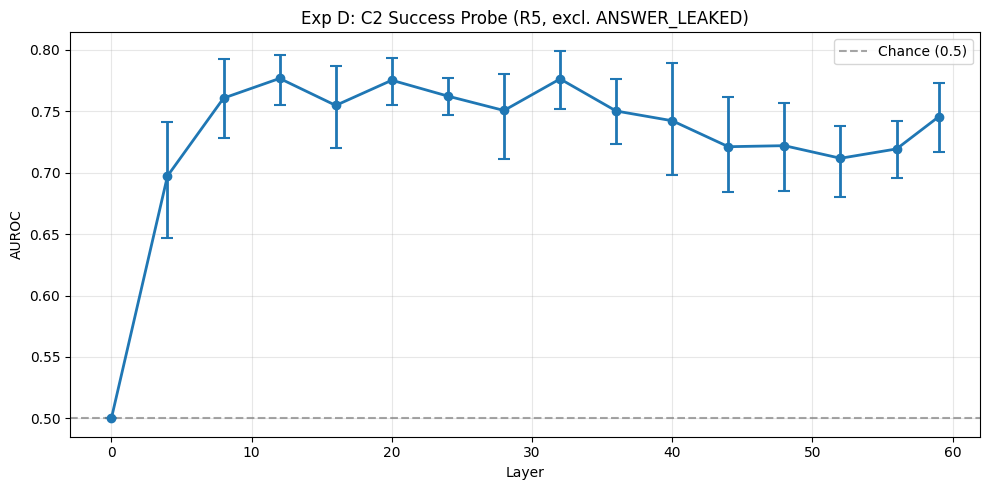

In [5]:
# Probe 1: Predict C2 success from last-token activations
# IMPORTANT: Exclude ANSWER_LEAKED samples -- these trivially succeed at C2
# and would inflate probe AUROC. Only use REASONING_LEGIBLE + ILLEGIBLE.
print("=== Probe: Predict C2 Success (excluding ANSWER_LEAKED) ===")

non_leaked_mask = np.array([
    m['label'] in ('REASONING_LEGIBLE', 'ILLEGIBLE')
    for m in r5_sample_meta
])
non_leaked_labels = r5_labels[non_leaked_mask]

print(f"Non-leaked samples: {non_leaked_mask.sum()} "
      f"(C2 success={non_leaked_labels.sum()}, failure={(1-non_leaked_labels).sum()})")

n_min_class = min(non_leaked_labels.sum(), (1 - non_leaked_labels).sum())
if n_min_class < 5:
    print(f"WARNING: Min class has only {n_min_class} samples -- probe may be unreliable")

c2_success_results = {}
for layer_idx in sorted(r5_last.keys()):
    features = r5_last[layer_idx][non_leaked_mask]
    if n_min_class < 5:
        print(f"  Layer {layer_idx}: skipping (min class={n_min_class})")
        continue

    result = train_binary_probe(features, non_leaked_labels, n_splits=min(5, n_min_class))
    c2_success_results[layer_idx] = result
    print(f"  Layer {layer_idx:3d}: AUROC={result['auroc']:.3f} CI={result['auroc_ci']}")

if c2_success_results:
    fig, ax = plot_layer_probe_curve(
        c2_success_results,
        title='Exp D: C2 Success Probe (R5, excl. ANSWER_LEAKED)',
        save_path=str(PHASE2_RESULTS_DIR / 'd_c2_success_probe_R5.png'),
    )
    plt.show()

In [6]:
# Probe 2: Predict C2 success from CoT boundary activations
# Exclude ANSWER_LEAKED (same filter as Probe 1)
print("=== Probe: Predict C2 Success (CoT boundary, excl. ANSWER_LEAKED) ===")

boundary_results = {}
for layer_idx in sorted(r5_boundary.keys()):
    features = r5_boundary[layer_idx][non_leaked_mask]
    if n_min_class < 5:
        continue

    result = train_binary_probe(features, non_leaked_labels, n_splits=min(5, n_min_class))
    boundary_results[layer_idx] = result
    print(f"  Layer {layer_idx:3d}: AUROC={result['auroc']:.3f} CI={result['auroc_ci']}")

=== Probe: Predict C2 Success (CoT boundary, excl. ANSWER_LEAKED) ===
  Layer   0: AUROC=0.500 CI=(0.5, 0.5)
  Layer   4: AUROC=0.696 CI=(0.6682378371402763, 0.7197352884243129)
  Layer   8: AUROC=0.720 CI=(0.6890677022841657, 0.7499322493224932)
  Layer  12: AUROC=0.704 CI=(0.6699703187508066, 0.7394650922699703)
  Layer  16: AUROC=0.711 CI=(0.6750711382113821, 0.7420667989417988)
  Layer  20: AUROC=0.767 CI=(0.7303276229190864, 0.8037875854949025)
  Layer  24: AUROC=0.760 CI=(0.7240095496193057, 0.7956252419667054)
  Layer  28: AUROC=0.733 CI=(0.6993128145567169, 0.7741773132017035)
  Layer  32: AUROC=0.756 CI=(0.7324074074074074, 0.774628984385082)
  Layer  36: AUROC=0.779 CI=(0.7497128661762809, 0.8050006452445476)
  Layer  40: AUROC=0.759 CI=(0.7337656471802813, 0.7847560975609756)
  Layer  44: AUROC=0.753 CI=(0.7247064137308039, 0.7753129436056266)
  Layer  48: AUROC=0.740 CI=(0.6971286617628081, 0.7767098980513614)
  Layer  52: AUROC=0.762 CI=(0.7170376822815847, 0.8066298877274

In [7]:
# Probe 3: Predict legibility class from R5 activations
# (excluding ANSWER_LEAKED)
print("=== Probe: Predict Legibility from R5 Activations ===")

leg_mask = np.array([
    m['label'] in ('REASONING_LEGIBLE', 'ILLEGIBLE')
    for m in r5_sample_meta
])
leg_labels = np.array([
    1 if m['label'] == 'REASONING_LEGIBLE' else 0
    for m in r5_sample_meta
])

print(f"Non-leaked samples: {leg_mask.sum()} "
      f"(legible={leg_labels[leg_mask].sum()}, illegible={(1-leg_labels[leg_mask]).sum()})")

if leg_mask.sum() >= 20:
    legibility_from_reader_results = {}
    for layer_idx in sorted(r5_last.keys()):
        features = r5_last[layer_idx][leg_mask]
        labels = leg_labels[leg_mask]

        result = train_binary_probe(features, labels, n_splits=5)
        legibility_from_reader_results[layer_idx] = result
        print(f"  Layer {layer_idx:3d}: AUROC={result['auroc']:.3f} CI={result['auroc_ci']}")
else:
    print("Insufficient non-leaked samples for this analysis")
    legibility_from_reader_results = {}

=== Probe: Predict Legibility from R5 Activations ===
Non-leaked samples: 388 (legible=100, illegible=288)
  Layer   0: AUROC=0.500 CI=(0.5, 0.5)
  Layer   4: AUROC=0.577 CI=(0.5337191470054446, 0.6260133091349063)
  Layer   8: AUROC=0.615 CI=(0.5704295220810648, 0.6717120387174833)
  Layer  12: AUROC=0.618 CI=(0.5838986690865093, 0.6521748336358136)
  Layer  16: AUROC=0.581 CI=(0.5136660617059892, 0.6485420447670901)
  Layer  20: AUROC=0.646 CI=(0.5946213702359348, 0.7037174833635813)
  Layer  24: AUROC=0.648 CI=(0.58832425892317, 0.7072837265577737)
  Layer  28: AUROC=0.640 CI=(0.5950332728372656, 0.6881336963097399)
  Layer  32: AUROC=0.565 CI=(0.503545069570478, 0.6317453115547489)
  Layer  36: AUROC=0.586 CI=(0.5187035692679977, 0.6531034482758622)
  Layer  40: AUROC=0.593 CI=(0.5392498487598306, 0.659080459770115)
  Layer  44: AUROC=0.597 CI=(0.5269933454325468, 0.6616905626134302)
  Layer  48: AUROC=0.591 CI=(0.5159013914095583, 0.6647172565033271)
  Layer  52: AUROC=0.581 CI=(0

In [10]:
# R5 perplexity covariate analysis
ds_scores = load_distributional_shift_scores()

# Get R5 perplexity for each sample
r5_perplexity = []
for m in r5_sample_meta:
    key = (m['sample_id'], m['generator_id'], m['epoch'], 'R5')
    entry = ds_scores.get(key)
    r5_perplexity.append(entry['reader_perplexity'] if entry else np.nan)
r5_perplexity = np.array(r5_perplexity, dtype=float)

valid_p = np.isfinite(r5_perplexity)
print(f"R5 perplexity available: {valid_p.sum()}/{len(r5_perplexity)}")

if valid_p.sum() >= 20 and c2_success_results:
    # Compare C2 success probe with vs without R5 perplexity
    best_layer = max(c2_success_results, key=lambda k: c2_success_results[k]['auroc'])
    # Apply both non_leaked and valid_perplexity masks
    combined_mask = non_leaked_mask & valid_p
    features_base = r5_last[best_layer][combined_mask]
    labels_p = r5_labels[combined_mask]
    perplexity_p = r5_perplexity[combined_mask]

    print(f"\nPerplexity covariate analysis at best layer {best_layer}:")
    print(f"  Samples with both labels and perplexity: {combined_mask.sum()}")

    # Without R5 perplexity
    r_no_p = train_binary_probe(features_base, labels_p)
    print(f"  Without R5 perplexity: AUROC={r_no_p['auroc']:.3f} CI={r_no_p['auroc_ci']}")

    # With R5 perplexity
    features_with_p = np.column_stack([features_base, perplexity_p.reshape(-1, 1)])
    r_with_p = train_binary_probe(features_with_p, labels_p)
    print(f"  With R5 perplexity:    AUROC={r_with_p['auroc']:.3f} CI={r_with_p['auroc_ci']}")

    # R5 perplexity only
    r_p_only = train_binary_probe(perplexity_p.reshape(-1, 1), labels_p)
    print(f"  R5 perplexity only:    AUROC={r_p_only['auroc']:.3f} CI={r_p_only['auroc_ci']}")
elif valid_p.sum() < 20:
    print("Insufficient R5 perplexity data -- run NB10b first.")
    print("Skipping perplexity covariate analysis.")

R5 perplexity available: 448/666

Perplexity covariate analysis at best layer 12:
  Samples with both labels and perplexity: 320
  Without R5 perplexity: AUROC=0.736 CI=(0.7104315585288369, 0.7612704667644185)
  With R5 perplexity:    AUROC=0.737 CI=(0.7104315585288369, 0.76328125)
  R5 perplexity only:    AUROC=0.577 CI=(0.45625, 0.6732748350439881)


## Per-Generator Probe Breakdown

The pooled probes above combine all generators. Here we split by generator to check
whether R5's C2 success prediction varies across G1, G2, and G3.

**Caveat**: G2 has very few non-leaked samples (~49 total, ~14 illegible), so its
results are indicative only and should not be over-interpreted.

In [ ]:
# Per-generator C2 success probes
per_gen_results = {}

for gid in ['G1', 'G2', 'G3']:
    # Filter to non-leaked samples from this generator
    gen_mask = np.array([
        m['generator_id'] == gid and m['label'] in ('REASONING_LEGIBLE', 'ILLEGIBLE')
        for m in r5_sample_meta
    ])
    gen_labels = r5_labels[gen_mask]

    n_total = gen_mask.sum()
    n_success = gen_labels.sum()
    n_failure = n_total - n_success
    n_min_class = min(n_success, n_failure)

    print(f"\n=== {gid}: {n_total} non-leaked samples "
          f"(C2 success={n_success}, failure={n_failure}) ===")

    if n_min_class < 5:
        print(f"  WARNING: min class has only {n_min_class} samples, skipping {gid}")
        per_gen_results[gid] = {'skipped': True, 'reason': f'min_class={n_min_class}'}
        continue

    if n_total < 49:
        print(f"  WARNING: G2 results are indicative only (n={n_total}, highly imbalanced)")

    gen_layer_results = {}
    n_splits = min(5, n_min_class)
    for layer_idx in sorted(r5_last.keys()):
        features = r5_last[layer_idx][gen_mask]
        result = train_binary_probe(features, gen_labels, n_splits=n_splits)
        gen_layer_results[layer_idx] = result
        print(f"  Layer {layer_idx:3d}: AUROC={result['auroc']:.3f} CI={result['auroc_ci']}")

    best_layer = max(gen_layer_results, key=lambda k: gen_layer_results[k]['auroc'])
    print(f"  Best: layer {best_layer}, AUROC={gen_layer_results[best_layer]['auroc']:.3f}")

    per_gen_results[gid] = {
        'n_samples': int(n_total),
        'n_success': int(n_success),
        'n_failure': int(n_failure),
        'layer_results': {int(k): {kk: vv for kk, vv in v.items()
                                    if kk not in ('probe_model', 'scaler', 'pipeline')}
                          for k, v in gen_layer_results.items()},
        'best_layer': int(best_layer),
        'best_auroc': gen_layer_results[best_layer]['auroc'],
    }

In [ ]:
# Plot per-generator C2 success AUROC comparison
fig, ax = plt.subplots(figsize=(10, 5))
colors = {'G1': 'C0', 'G2': 'C1', 'G3': 'C2'}
labels_map = {'G1': 'G1 (R1-Distill-32B)', 'G2': 'G2 (o3-mini)', 'G3': 'G3 (QwQ-32B)'}

for gid in ['G1', 'G2', 'G3']:
    gen_data = per_gen_results.get(gid, {})
    if gen_data.get('skipped'):
        continue

    layer_data = gen_data.get('layer_results', {})
    if not layer_data:
        continue

    layers = sorted(int(k) for k in layer_data.keys())
    aurocs = [layer_data[str(l) if str(l) in layer_data else l]['auroc'] for l in layers]
    ci_data = [layer_data[str(l) if str(l) in layer_data else l].get('auroc_ci', [0.5, 0.5])
               for l in layers]
    yerr = [[a - ci[0] for a, ci in zip(aurocs, ci_data)],
            [ci[1] - a for a, ci in zip(aurocs, ci_data)]]

    n = gen_data.get('n_samples', '?')
    linestyle = '--' if gid == 'G2' else '-'
    label = f"{labels_map[gid]} (n={n})"
    if gid == 'G2':
        label += " [indicative]"

    ax.errorbar(layers, aurocs, yerr=yerr, fmt='o' + linestyle, capsize=3,
                linewidth=2, markersize=5, label=label, color=colors[gid])

ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Chance')
ax.set_xlabel('Layer')
ax.set_ylabel('AUROC')
ax.set_title('R5 Per-Generator C2 Success Probe')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_ylim(0.3, 1.0)
fig.tight_layout()
fig.savefig(str(PHASE2_RESULTS_DIR / 'd_per_generator_r5.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Reader CKA summary: load from cka_results.json if available, else compute inline
cka_path = PHASE2_RESULTS_DIR / 'cka_results.json'
r5_cka_loaded = False

if cka_path.exists():
    with open(cka_path) as f:
        cka_data = json.load(f)
    if 'R5_legibility_cka' in cka_data:
        r5_cka_loaded = True
        print("Loaded R5 CKA from cka_results.json (computed in NB04)")
        r5_leg_cka = cka_data['R5_legibility_cka']
        r5_c2_cka = cka_data.get('R5_c2_success_cka', {})

        # Plot
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

        layers = sorted(int(k) for k in r5_leg_cka.keys())
        vals = [r5_leg_cka[str(l)]['cka'] for l in layers]
        ci = [r5_leg_cka[str(l)].get('cka_ci', [0, 1]) for l in layers]
        yerr = [[max(v - c[0], 0) for v, c in zip(vals, ci)],
                [max(c[1] - v, 0) for v, c in zip(vals, ci)]]
        ax1.errorbar(layers, vals, yerr=yerr, fmt='o-', capsize=4, linewidth=2)
        ax1.set_xlabel('Layer')
        ax1.set_ylabel('Linear CKA')
        ax1.set_title('R5: Legible vs Illegible CKA')
        ax1.grid(alpha=0.3)

        if r5_c2_cka:
            layers2 = sorted(int(k) for k in r5_c2_cka.keys())
            vals2 = [r5_c2_cka[str(l)]['cka'] for l in layers2]
            ci2 = [r5_c2_cka[str(l)].get('cka_ci', [0, 1]) for l in layers2]
            yerr2 = [[max(v - c[0], 0) for v, c in zip(vals2, ci2)],
                     [max(c[1] - v, 0) for v, c in zip(vals2, ci2)]]
            ax2.errorbar(layers2, vals2, yerr=yerr2, fmt='s-', capsize=4,
                         linewidth=2, color='C1')
        ax2.set_xlabel('Layer')
        ax2.set_title('R5: C2 Success vs Failure CKA')
        ax2.grid(alpha=0.3)

        fig.suptitle('Reader-Side CKA Summary (from NB04)', fontsize=13)
        fig.tight_layout()
        plt.show()

if not r5_cka_loaded:
    print("R5 CKA not found in cka_results.json -- run NB04 with R5 CKA first.")
    print("Computing inline as fallback...")

    # Inline CKA computation (same approach as NB04)
    def linear_cka_fast(X, Y):
        X = X - X.mean(axis=0, keepdims=True)
        Y = Y - Y.mean(axis=0, keepdims=True)
        GX = X @ X.T
        GY = Y @ Y.T
        hsic_xy = np.sum(GX * GY)
        hsic_xx = np.sum(GX * GX)
        hsic_yy = np.sum(GY * GY)
        denom = np.sqrt(hsic_xx * hsic_yy)
        return float(hsic_xy / denom) if denom > 0 else 0.0

    rng_cka = np.random.RandomState(42)
    leg_idx_cka = np.where(np.array([m['label'] == 'REASONING_LEGIBLE' for m in r5_sample_meta]))[0]
    ill_idx_cka = np.where(np.array([m['label'] == 'ILLEGIBLE' for m in r5_sample_meta]))[0]
    n_match_cka = min(len(leg_idx_cka), len(ill_idx_cka))
    if len(ill_idx_cka) > n_match_cka:
        ill_idx_cka = rng_cka.choice(ill_idx_cka, size=n_match_cka, replace=False)

    r5_leg_cka_inline = {}
    for layer_idx in sorted(r5_last.keys()):
        X_l = r5_last[layer_idx][leg_idx_cka[:n_match_cka]]
        X_i = r5_last[layer_idx][ill_idx_cka]
        cka_val = linear_cka_fast(X_l, X_i)
        boot_ckas = []
        for _ in range(1000):
            idx = rng_cka.choice(n_match_cka, size=n_match_cka, replace=True)
            boot_ckas.append(linear_cka_fast(X_l[idx], X_i[idx]))
        boot_ckas = np.array(boot_ckas)
        r5_leg_cka_inline[layer_idx] = {
            'cka': float(cka_val),
            'cka_ci': (float(np.percentile(boot_ckas, 2.5)), float(np.percentile(boot_ckas, 97.5))),
        }
        print(f"  Layer {layer_idx}: CKA={cka_val:.3f}")

    # Assign for downstream use
    r5_leg_cka = {str(k): v for k, v in r5_leg_cka_inline.items()}

In [ ]:
# Save results (including per-generator breakdown)
def clean_results(d):
    return {int(k): {kk: vv for kk, vv in v.items() if kk not in ('probe_model', 'scaler', 'pipeline')}
            for k, v in d.items()}

output = {
    'c2_success_probe': clean_results(c2_success_results),
    'boundary_probe': clean_results(boundary_results),
    'legibility_from_reader': clean_results(legibility_from_reader_results),
    'per_generator_c2': per_gen_results,
}
output_path = PHASE2_RESULTS_DIR / 'reader_r5_analysis_results.json'
with open(output_path, 'w') as f:
    json.dump(output, f, indent=2, default=str)
print(f"Saved to {output_path}")

# Print summary
print("\n--- R5 Analysis Summary ---")
for probe_name, results in [('C2 Success (last-token)', c2_success_results),
                             ('C2 Success (boundary)', boundary_results),
                             ('Legibility', legibility_from_reader_results)]:
    if results:
        best_layer = max(results, key=lambda k: results[k]['auroc'])
        best_auroc = results[best_layer]['auroc']
        print(f"  {probe_name}: best layer={best_layer}, AUROC={best_auroc:.3f}")

print("\n--- Per-Generator C2 Success ---")
for gid in ['G1', 'G2', 'G3']:
    gen_data = per_gen_results.get(gid, {})
    if gen_data.get('skipped'):
        print(f"  {gid}: skipped ({gen_data.get('reason', 'unknown')})")
    else:
        print(f"  {gid}: best layer={gen_data['best_layer']}, "
              f"AUROC={gen_data['best_auroc']:.3f}, n={gen_data['n_samples']}")